using tustin discretisation to initialise the NN at the discrete matricies. 

using batch training to arrive at the solution

In [348]:

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import ast


In [349]:
plt.rcParams["font.family"]   = "DejaVu Sans"  # or "Times New Roman", etc.
plt.rcParams["font.size"]     = 8           # base font size
plt.rcParams["axes.titlesize"] = 10        # all titles
plt.rcParams["axes.labelsize"] = 8         # all x/y labels


In [350]:
dtype=torch.float32
device = 'cpu'

In [351]:
txt = open("N=10000-dt=2.5e-05-force=sin(2pi200t).txt").read().split('\t')
         # list of strings
f = np.array(txt, dtype=float)      # 30000 floats
t = torch.tensor(f[:10000], dtype =dtype)
u= torch.tensor(f[10000:20000],dtype =dtype)
x = torch.tensor(f[20000:30000],dtype =dtype)
v = torch.tensor(f[30000:],dtype =dtype)
print(len(f))
print(x)


40000
tensor([0.0000e+00, 0.0000e+00, 1.9632e-11,  ..., 5.7095e-08, 3.3124e-08,
        9.1173e-09])


In [352]:
#normalisation 


def zscore_normalize(x: torch.Tensor):
    """
    x: 1D tensor (N,) or (N,1)
    returns: x_norm, mean, std  with x_norm = (x-mean)/std
    """
    if x.dim() == 2 and x.size(1) == 1:
        x = x.view(-1)

    mean = x.mean()
    std = x.std(unbiased=False)  # population std; use unbiased=True if you prefer

    # avoid divide by zero
    std_safe = std.clone()
    if std_safe == 0:
        std_safe = torch.tensor(1.0, dtype=x.dtype, device=x.device)

    x_norm = (x - mean) / std_safe
    return x_norm, mean, std_safe


def zscore_denormalize(x_norm: torch.Tensor, mean: torch.Tensor, std: torch.Tensor):
    """
    Invert z-score: x = x_norm * std + mean
    """
    print('noir')
    print(x_norm)
    print('std')
    print(std)
    return x_norm * std + mean


In [353]:
x_train_norm, x_mean, x_std = zscore_normalize(x)
u_train_norm, u_mean, u_std = zscore_normalize(u)
v_train_norm, v_mean, v_std = zscore_normalize(v)




u_v = torch.stack([x[1:], v[1:]] , dim = 0)

Z = torch.stack([x[:-1], v[:-1], u[:-1]], dim=1)  # shape (T-1, 3)
print(Z[0,:].size())
# Targets Y_t = [x_t, v_t]
Y = torch.stack([x[1:], v[1:]], dim=1) 

# Closed-form LS: Y ≈ Z W, W shape (3,2)
Z_T = Z.T                                          # (3, T-1)
W_star = torch.linalg.lstsq(Z_T @ Z, Z_T @ Y).solution  # (3,2)
# Or, more simply (but less stable): W_star = torch.linalg.inv(Z_T @ Z) @ (Z_T @ Y)


torch.Size([3])


In [354]:
k = (2*np.pi*100)**2
m = 1
zeta, f_n = 0.015, 100.0      # 100 Hz
wn = 2 * np.pi * f_n
c = 2 * zeta * m * wn

# dt = t[1].item()
dt = 2.5e-5
N = len(t)
print(N)
print(dt)
N_list = np.arange(N)*dt
Nl = torch.tensor(N_list, dtype=dtype, device=device)
print(f'time increment: {dt} s, total time: {N*dt} s')
I2 = torch.tensor([[1,0],[0,1]], dtype=dtype).to(device)
A2 = torch.tensor([[0,1],[-k/m,-c/m]], dtype=dtype).to(device)
B2 = torch.tensor([[0],[1/m]], dtype=dtype).to(device)


Adisc = torch.linalg.inv(I2-dt*0.5*A2)@(I2+dt*0.5*A2)
Bdisc = torch.linalg.inv(I2-dt*0.5*A2)@(dt*B2)

x0 = torch.tensor([0,0],dtype=torch.float32)
x0_n = torch.tensor([x_train_norm[0],v_train_norm[0]],dtype=torch.float32)
##tustin discretization

10000
2.5e-05
time increment: 2.5e-05 s, total time: 0.25 s


In [355]:
class NARX(nn.Module):
    def __init__(self, A =None, B =None):
        super().__init__()
        self.hidden = nn.Linear(3, 2, bias=False)
      
        with torch.no_grad():
            if A != None:
                C = torch.cat((A,B), dim =1)
                self.hidden.weight[:] = C
                print(C)
            
    def forward(self, u, x0 = torch.tensor([0,0],dtype=torch.float32)):
        # closed loop rollout
        out = [x0]
        for i in range(1, len(u)):
            x_prev = out[i-1]                       # previous state 
            u_prev = u[i-1].view(1)                 # previous external input
            inp = torch.cat((x_prev, u_prev), dim=0)# model input 
            xi = self.hidden(inp)                   # apply learned weights to input
            out.append(xi)
        return torch.stack(out, dim=0)[:,0]         # C= [1,0] therefore x_1 is first entry of each state in 'out'
    

    
    def open_loop_train(self, Z):
        # open loop 
        return self.hidden(Z)


tensor([[ 9.9988e-01,  2.4993e-05,  3.1241e-10],
        [-9.8667e+00,  9.9941e-01,  2.4993e-05]])
tensor(1.4154e-16, grad_fn=<MseLossBackward0>)
tensor([0.0000e+00, 0.0000e+00, 9.8129e-12,  ..., 6.5287e-08, 4.1355e-08,
        1.7376e-08])
tensor([0.0000e+00, 0.0000e+00, 1.9632e-11,  ..., 5.7095e-08, 3.3124e-08,
        9.1173e-09])


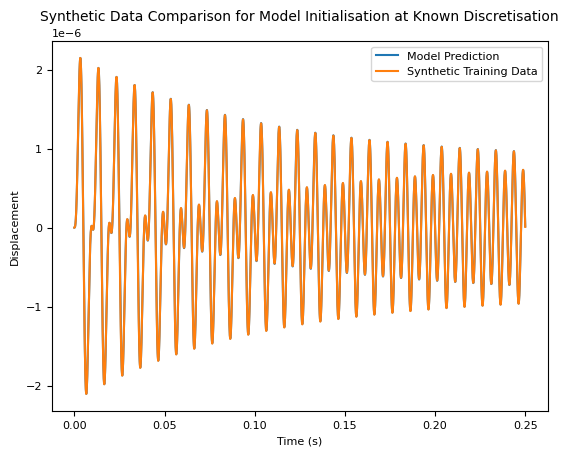

In [356]:
test = NARX(Adisc, Bdisc)

ypred = test(u)
# ypred = zscore_denormalize(ypred, x_mean, x_std)

print(nn.MSELoss()(x, ypred))
print(ypred.detach())
print(x.detach())
plt.figure()
plt.plot(t, ypred.detach(), label = 'Model Prediction')
plt.plot(t, x.detach(), label = 'Synthetic Training Data')
plt.title("Synthetic Data Comparison for Model Initialisation at Known Discretisation")
plt.xlabel("Time (s)")          # x‑axis label
plt.ylabel("Displacement")  # y‑axis label

plt.legend()
plt.show()




#### uncomment when dtaa changes!!!!

# data = [['time'],t.numpy(),['synthetic x'], x,['model initialisation'], ypred]

# filename = f'Data/1-SyntheticVSmodelInitialisation.txt'

# tstr = '\t'.join(str(x) for lst in data for x in lst)

# with open(filename, "w") as f:
#   f.write(tstr)


In [357]:
# loss functions
def batch_loss(pred, target, model=None):
    
    z = nn.MSELoss()(pred, target)
    return z


In [358]:
# training
def train_model(model, optimizer, x_train, v_train, f_train, epochs=5000, exit = 1e-14, loss_fn=batch_loss):
    model.train()
     # CORRECT SHAPES: Z (N-1, 3), Y_target (N-1, 2)
    Z= torch.stack([x_train[:-1], v_train[:-1], f_train[:-1]], dim=1)  # (N-1, 3)
    Y_target = torch.stack([x_train[1:], v_train[1:]], dim=1)                     # (N-1, 2)
    for epoch in range(epochs):
        optimizer.zero_grad()
    
        pred = model.open_loop_train(Z)
        target = Y_target
  
        # print(f'shape uvnorm {uvnorm.size()}, shape pred {pred.size()}')
        loss = nn.MSELoss()(pred, target)
        loss.backward()
        optimizer.step()
        
        if epoch % 100000 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item()}")
        if loss.item() < exit:
            print(f"Early stopping at epoch {epoch}, Loss: {loss.item()}")
            break

In [359]:
model = NARX()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

noir
tensor([-0.0120,  0.0011, -0.0231,  ...,  0.0836,  0.0634,  0.0431],
       grad_fn=<SelectBackward0>)
std
tensor(8.1011e-07)
pred tensor([ 0.0000e+00,  1.0606e-08, -8.9907e-09,  ...,  7.7451e-08,
         6.1092e-08,  4.4681e-08], grad_fn=<AddBackward0>)
x tensor([0.0000e+00, 0.0000e+00, 1.9632e-11,  ..., 5.7095e-08, 3.3124e-08,
        9.1173e-09])
 initial loss: 3.5190909431284667e-13


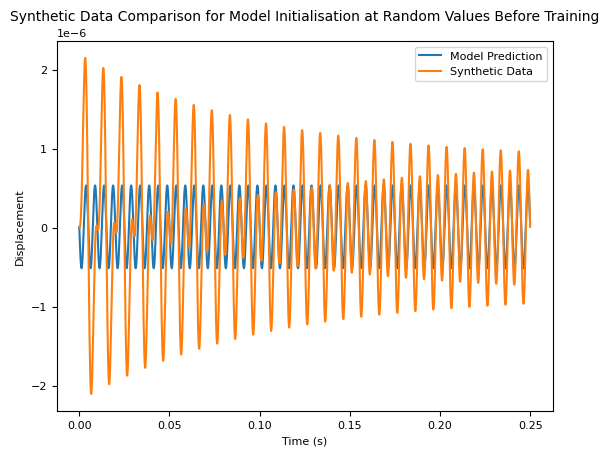

In [360]:
x0_norm = torch.tensor([x_train_norm[0],v_train_norm[0]],dtype=torch.float32)
pred = model(u_train_norm,x0_norm )
pred= zscore_denormalize(pred,x_mean, x_std)
print(f'pred {pred}')
print(f'x {x}')
print(f' initial loss: {nn.MSELoss()(pred,x)}')

plt.plot(t,pred.detach(), label = 'Model Prediction')
plt.plot(t,x, label  = 'Synthetic Data')
plt.legend()
plt.title("Synthetic Data Comparison for Model Initialisation at Random Values Before Training")
plt.xlabel("Time (s)")          # x‑axis label
plt.ylabel("Displacement")
plt.show()
##### uncomment when dtaa changes!!!!

# data = [['time'],t.numpy(),['synthetic x'], x,['model initialisation'], pred]

# filename = f'Data/2-2neuronnarx-batch-random-init-before-train.txt'

# tstr = '\t'.join(str(x) for lst in data for x in lst)

# with open(filename, "w") as f:
#   f.write(tstr)

In [361]:
train_model(model, optimizer, x_train_norm[:4000],v_train_norm[:4000], u_train_norm[:4000], exit = 7e-9,epochs=1000000)
# prediction_loop(model, x_train, f_train

Epoch 0, Loss: 1.1186822652816772
Early stopping at epoch 423, Loss: 6.978416511316254e-09


noir
tensor([-0.0120, -0.0120, -0.0120,  ...,  0.0724,  0.0425,  0.0126],
       grad_fn=<SelectBackward0>)
std
tensor(8.1011e-07)


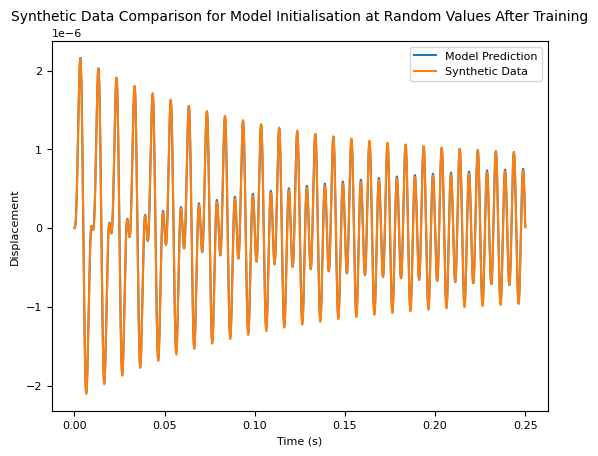

In [362]:
predaf = model(u_train_norm, x0_norm)

predaf = zscore_denormalize(predaf, x_mean, x_std)

plt.plot(t,predaf.detach(), label = 'Model Prediction')
plt.plot(t,x, label  = 'Synthetic Data')
plt.legend()
plt.title("Synthetic Data Comparison for Model Initialisation at Random Values After Training")
plt.xlabel("Time (s)")          # x‑axis label
plt.ylabel("Displacement")
plt.show()

# data = [['time'],t.numpy(),['synthetic x'], x,['model after train'], predaf]

# filename = f'Data/3-2neuronnarx-batch-random-init-after-train.txt'

# tstr = '\t'.join(str(x) for lst in data for x in lst)

# with open(filename, "w") as f:
#   f.write(tstr)

In [363]:
txt1 = open("N=10000-dt=2.5e-05-force=sin(2pi500t).txt").read().split('\t')
         # list of strings
f1 = np.array(txt1, dtype=float)   

t1=f1[:10000]  # 30000 floats
t1 = torch.tensor(t1, dtype =dtype)
u1 = f1[10000:20000]
u1= torch.tensor(u1,dtype =dtype)
x1=f1[20000:30000]
x1 = torch.tensor(x1,dtype =dtype)
v1=f1[30000:]
v1 = torch.tensor(v1,dtype =dtype)



In [364]:
u1_norm, u1_mean, u1_std = zscore_normalize(u1)
x1_norm , x1_mean, x1_std = zscore_normalize(x1)
v1_norm , v1_mean, v1_std = zscore_normalize(v1)
x01_norm = torch.tensor([x1_norm[0],v1_norm[0]],dtype=torch.float32)
test_pred = model(u1_norm, x01_norm)

print(test_pred[0])
print(model(u1)[0])
print(u1[0])
print(u1_norm[0])
# test_pred = zscore_denormalize(test_pred, x_mean,x_std)


tensor(-0.0163, grad_fn=<SelectBackward0>)
tensor(0., grad_fn=<SelectBackward0>)
tensor(0.)
tensor(0.)


noir
tensor([-0.0163, -0.0163, -0.0162,  ...,  0.0267,  0.0176,  0.0083],
       grad_fn=<SelectBackward0>)
std
tensor(8.1011e-07)


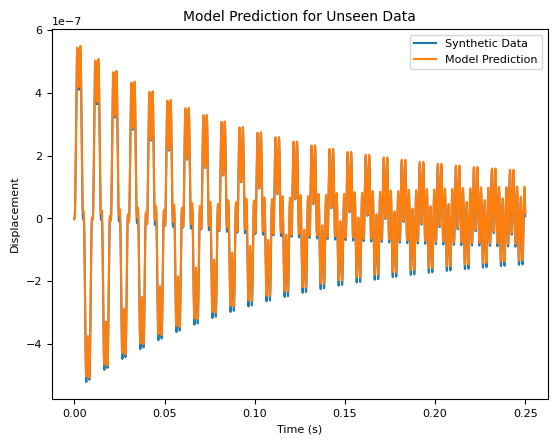

tensor(0.)
tensor(-3.4640e-09, grad_fn=<SelectBackward0>)


In [365]:
test_pred = zscore_denormalize(test_pred, x_mean,x_std)
plt.plot(t, x1, label = 'Synthetic Data')
plt.plot(t, test_pred.detach(), label = 'Model Prediction')
plt.legend()

plt.title("Model Prediction for Unseen Data")
plt.xlabel("Time (s)")          # x‑axis label
plt.ylabel("Displacement")
plt.show()

# data = [['time'],t.numpy(),['synthetic x'], x1,['model after train unseen'], test_pred]

# filename = f'Data/4-2neuronnarx-batch-unseen-data.txt'

# tstr = '\t'.join(str(x) for lst in data for x in lst)

# with open(filename, "w") as f:
#   f.write(tstr)

print(x1[0])
print( test_pred[0])